In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Loading product data, keep only relevant columns
product_df = pd.read_csv("product_info.csv")
product_df = product_df[["product_id", "product_name", "loves_count", "rating", "reviews", "ingredients", "price_usd", "highlights", "primary_category", "secondary_category", "tertiary_category"]]

product_df.info()
product_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          8494 non-null   object 
 1   product_name        8494 non-null   object 
 2   loves_count         8494 non-null   int64  
 3   rating              8216 non-null   float64
 4   reviews             8216 non-null   float64
 5   ingredients         7549 non-null   object 
 6   price_usd           8494 non-null   float64
 7   highlights          6287 non-null   object 
 8   primary_category    8494 non-null   object 
 9   secondary_category  8486 non-null   object 
 10  tertiary_category   7504 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 730.1+ KB


,product_id,product_name,loves_count,rating,reviews,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category
0,P473671,Fragrance Discovery Set,6320,3.6364,11.0,"['Capri Eau de Parfum:', 'Alcohol Denat. (SD A...",35.0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets
1,P473668,La Habana Eau de Parfum,3827,4.1538,13.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume
2,P473662,Rainbow Bar Eau de Parfum,3253,4.2500,16.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume
3,P473660,Kasbah Eau de Parfum,3018,4.4762,21.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume
4,P473658,Purple Haze Eau de Parfum,2691,3.2308,13.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume


In [2]:
#Loading and concatenating all reviews datasets, keep only relevant columns
reviews1 = pd.read_csv("reviews_0-250.csv")
reviews2 = pd.read_csv("reviews_250-500.csv")
reviews3 = pd.read_csv("reviews_500-750.csv")
reviews4 = pd.read_csv("reviews_750-1250.csv")
reviews5 = pd.read_csv("reviews_1250-end.csv")

reviews_df = pd.concat(
    [reviews1, reviews2, reviews3, reviews4, reviews5],
    ignore_index=True
)

reviews_df = reviews_df.drop_duplicates()
reviews_df = reviews_df[["product_id", "product_name", "rating", "is_recommended", "total_feedback_count", "total_pos_feedback_count", "review_text"]]

reviews_df.info()
reviews_df.head()

C:\Users\charl\AppData\Local\Temp\ipykernel_21804\1008845895.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews1 = pd.read_csv("reviews_0-250.csv")
C:\Users\charl\AppData\Local\Temp\ipykernel_21804\1008845895.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews4 = pd.read_csv("reviews_750-1250.csv")
C:\Users\charl\AppData\Local\Temp\ipykernel_21804\1008845895.py:6: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews5 = pd.read_csv("reviews_1250-end.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094411 entries, 0 to 1094410
Data columns (total 7 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   product_id                1094411 non-null  object 
 1   product_name              1094411 non-null  object 
 2   rating                    1094411 non-null  int64  
 3   is_recommended            926423 non-null   float64
 4   total_feedback_count      1094411 non-null  int64  
 5   total_pos_feedback_count  1094411 non-null  int64  
 6   review_text               1092967 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 58.4+ MB


,product_id,product_name,rating,is_recommended,total_feedback_count,total_pos_feedback_count,review_text
0,P504322,Gentle Hydra-Gel Face Cleanser,5,1.0,2,2,I use this with the Nudestix “Citrus Clean Bal...
1,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,1,0.0,0,0,I bought this lip mask after reading the revie...
2,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,5,1.0,0,0,My review title says it all! I get so excited ...
3,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,5,1.0,0,0,I’ve always loved this formula for a long time...
4,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,5,1.0,0,0,"If you have dry cracked lips, this is a must h..."


In [3]:
#Filter for only skincare in products dataset
product_df = product_df[
    product_df["primary_category"].str.contains("Skincare", case=False, na=False)|
    product_df["secondary_category"].str.contains("Skincare", case=False, na=False)|
    product_df["tertiary_category"].str.contains("Skincare", case=False, na=False)
]

reviews_df = reviews_df[reviews_df['product_id'].isin(product_df['product_id'])]
print(product_df.shape)
print(reviews_df.shape)

reviews_df['product_id'].value_counts()

(2522, 11)
(1094411, 7)


product_id
P420652    16138
P7880       8736
P218700     7763
P248407     7547
P269122     7414
           ...  
P480441        1
P469829        1
P505174        1
P476571        1
P504322        1
Name: count, Length: 2351, dtype: int64

In [4]:
#Check for null values
print(product_df.isna().sum())
print(reviews_df.isna().sum())

product_id              0
product_name            0
loves_count             0
rating                 73
reviews                73
ingredients           143
price_usd               0
highlights            448
primary_category        0
secondary_category      0
tertiary_category     446
dtype: int64
product_id                       0
product_name                     0
rating                           0
is_recommended              167988
total_feedback_count             0
total_pos_feedback_count         0
review_text                   1444
dtype: int64


In [5]:
#Drop null rows that may affect analysis
product_df = product_df[product_df["rating"].notna()]
product_df = product_df[product_df["ingredients"].notna()]

reviews_df = reviews_df[reviews_df["is_recommended"].notna()]

In [6]:
print("Products:", product_df.shape)
print("Unique Products:", product_df["product_id"].nunique())

print("Reviews:", reviews_df.shape)
print("Unique Reviewed Products:", reviews_df["product_id"].nunique())

Products: (2313, 11)
Unique Products: 2313
Reviews: (926423, 7)
Unique Reviewed Products: 2351


In [7]:
#Remove mini size products
product_df = product_df[~(
        product_df["primary_category"].str.contains("Mini Size", case=False, na=False)|
        product_df["secondary_category"].str.contains("Mini Size", case=False, na=False)|
        product_df["tertiary_category"].str.contains("Mini Size", case=False, na=False)
    )
]

#Update reviews dataset for removed products
reviews_df = reviews_df[reviews_df["product_id"].isin(product_df["product_id"])]

In [8]:
#Clean price data, create price bands
product_df = product_df[(product_df["price_usd"].notna()) & (product_df["price_usd"] > 0)]
product_df["price_band"] = pd.cut(
    product_df["price_usd"],
    bins=[0, 20, 40, 60, 80, 200],
    labels=["0–20", "20–40", "40–60", "60–80", "80+"]
)

#Update reviews dataset for removed products
reviews_df = reviews_df[reviews_df["product_id"].isin(product_df["product_id"])]

In [9]:
#Aggregate reviews to product level
review_agg = reviews_df.groupby("product_id").agg(
    total_reviews=("rating", "count"),
    recommend_rate=("is_recommended", "mean"),
    total_positive=("total_pos_feedback_count", "sum"),
    total_feedback=("total_feedback_count", "sum")
).reset_index()

review_agg["positive_feedback_ratio"] = (review_agg["total_positive"] / review_agg["total_feedback"])

In [10]:
#Merge aggregated reviews with products, drop products with no reviews
final_df = product_df.merge(review_agg, on="product_id", how="left")
final_df = final_df[final_df["total_reviews"].notna()]

final_df.shape

(2117, 17)

In [11]:
#Determining a minimum review threshold by looking at distribution (how many reviews products have on avg)
final_df["total_reviews"].describe()
final_df["total_reviews"].quantile([0.1, 0.25, 0.5, 0.75, 0.9])

for n in [1, 5, 10, 15, 20, 35]:
    count = (final_df["total_reviews"] < n).sum()
    print(f"Products with < {n} reviews: {count}")

Products with < 1 reviews: 0
Products with < 5 reviews: 118
Products with < 10 reviews: 209
Products with < 15 reviews: 303
Products with < 20 reviews: 382
Products with < 35 reviews: 529


In [12]:
#Setting minimum review threshold at 10 
final_df = final_df[final_df["total_reviews"] >= 10]

print("Final dataset shape:", final_df.shape)
print("Unique products:", final_df["product_id"].nunique())

Final dataset shape: (1908, 17)
Unique products: 1908


In [13]:
final_df

,product_id,product_name,loves_count,rating,reviews,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category,price_band,total_reviews,recommend_rate,total_positive,total_feedback,positive_feedback_ratio
0,P439055,GENIUS Sleeping Collagen Moisturizer,33910,4.5413,1321.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Ethylh...",98.0,"['Vegan', 'Good for: Loss of firmness', 'Colla...",Skincare,Moisturizers,Moisturizers,80+,1321.0,0.920515,2798.0,3467.0,0.807038
1,P421277,GENIUS Liquid Collagen Serum,67870,4.0259,1159.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Propan...",115.0,"['Vegan', 'Good for: Loss of firmness', 'Colla...",Skincare,Treatments,Face Serums,80+,1126.0,0.762877,8131.0,10025.0,0.811072
2,P467602,Triple Algae Eye Renewal Balm Eye Cream,17890,4.5306,1142.0,"['Aqua (Water/Eau), Stearic Acid, Isopropyl Is...",68.0,NaN,Skincare,Eye Care,Eye Creams & Treatments,60–80,1142.0,0.938704,1330.0,1730.0,0.768786
3,P432045,GENIUS Liquid Collagen Lip Treatment,44448,3.8721,649.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Glycer...",29.0,"['Vegan', 'Good for: Loss of firmness', 'Plump...",Skincare,Lip Balms & Treatments,NaN,20–40,649.0,0.713405,4527.0,5413.0,0.836320
4,P311143,SUBLIME DEFENSE Ultra Lightweight UV Defense F...,27278,4.4134,508.0,"['Octinoxate 7.5%, Titanium Dioxide 2%, Zinc O...",28.0,"['Vegan', 'Hypoallergenic', 'UV Protection', '...",Skincare,Sunscreen,Face Sunscreen,20–40,232.0,0.814655,698.0,803.0,0.869240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2143,P416923,Superfood Hydrate + Firm Peptide Eye Cream,38812,3.6564,326.0,"['Water/Aqua/Eau (Aqua), Helianthus Annuus (Su...",38.0,"['Hyaluronic Acid', 'Good for: Loss of firmnes...",Skincare,Eye Care,Eye Creams & Treatments,20–40,287.0,0.609756,1547.0,1964.0,0.787678
2144,P482329,Retinal + Niacinamide Youth Serum,41445,4.5841,315.0,"['Water/Aqua/Eau, Butylene Glycol, Triethylhex...",69.0,"['Good for: Dullness/Uneven Texture', 'Clean +...",Skincare,Treatments,Face Serums,60–80,317.0,0.940063,680.0,1066.0,0.637899
2145,P502479,Kombucha + 10% AHA Liquid Exfoliant with Lacti...,11299,4.5926,81.0,"['Water/Aqua/Eau, Pentylene Glycol, Lactic Aci...",42.0,"['Good for: Dullness/Uneven Texture', 'Lactic ...",Skincare,Cleansers,Exfoliators,40–60,82.0,0.926829,130.0,170.0,0.764706
2146,P473336,The Youth System,53522,4.5526,76.0,"['Superfood Antioxidant Cleanser:', 'Water/Aqu...",59.0,"['Vegan', 'Vitamin C', 'Good for: Pores', 'Cle...",Skincare,Value & Gift Sets,NaN,40–60,77.0,0.896104,522.0,714.0,0.731092


In [14]:
final_df.to_csv("cleaned_dataset.csv", index=False)

**Price Bands vs Customer Satisfaction**

In [15]:
# group to product level
price_bands_eda_df = final_df.groupby('product_id').agg(
    price_usd=('price_usd', 'first'),     # taking the price
    recommendation_rate=('recommend_rate', 'mean'),     # calculate average recommendation
    total_reviews=('total_reviews', 'first'),      # Use 'first' to get the already calculated total reviews
    rating=('rating', 'mean'), # Include rating in the aggregation
    product_name=('product_name', 'first') # Include product_name in the aggregation
).reset_index()

In [16]:
print("Total reviews per product:")
display(final_df[['product_id', 'product_name', 'total_reviews']].head())

print("\nSummary statistics for total reviews:")
display(final_df['total_reviews'].describe())

Total reviews per product:


,product_id,product_name,total_reviews
0,P439055,GENIUS Sleeping Collagen Moisturizer,1321.0
1,P421277,GENIUS Liquid Collagen Serum,1126.0
2,P467602,Triple Algae Eye Renewal Balm Eye Cream,1142.0
3,P432045,GENIUS Liquid Collagen Lip Treatment,649.0
4,P311143,SUBLIME DEFENSE Ultra Lightweight UV Defense F...,232.0



Summary statistics for total reviews:


count     1908.000000
mean       437.773585
std        779.011648
min         10.000000
25%         55.000000
50%        186.000000
75%        485.000000
max      15899.000000
Name: total_reviews, dtype: float64

In [17]:
products_over_100 = final_df[final_df['total_reviews'] > 50]
print(f"Number of products with more than 100 reviews: {len(products_over_100)}")

Number of products with more than 100 reviews: 1463


In [18]:
price_bands_eda_df = price_bands_eda_df[price_bands_eda_df['total_reviews'] > 50]

# looking to see which products have 50+ reviews -- but this can be changed at any point

In [19]:
price_bands_eda_df["price_band"] = pd.cut(
    price_bands_eda_df["price_usd"],
    bins=[0, 20, 40, 60, 80, 200],
    labels=["0–20", "20–40", "40–60", "60–80", "80+"]
)

print("New price bands applied to price_bands_eda_df:")
display(price_bands_eda_df[['product_name', 'price_usd', 'price_band']].head())

New price bands applied to price_bands_eda_df:


,product_name,price_usd,price_band
0,Renewing Eye Cream,89.0,80+
1,Goodbye Acne Max Complexion Correction Pads,48.0,40–60
2,Grape Water Moisturizing Face Mist,12.0,0–20
4,7 Day Face Scrub Cream Rinse-Off Formula,26.0,20–40
5,Exfoliating Face Scrub,26.0,20–40


In [20]:
price_summary_specific_bins = price_bands_eda_df.groupby('price_band', observed=True)['recommendation_rate'].agg(
    ['mean', 'std', 'count']
)

print("Price Summary with specific bins:")
print(price_summary_specific_bins)

Price Summary with specific bins:
                mean       std  count
price_band                           
0–20        0.799614  0.111842    201
20–40       0.834301  0.097890    465
40–60       0.854232  0.093359    368
60–80       0.863408  0.097853    226
80+         0.854567  0.112288    173


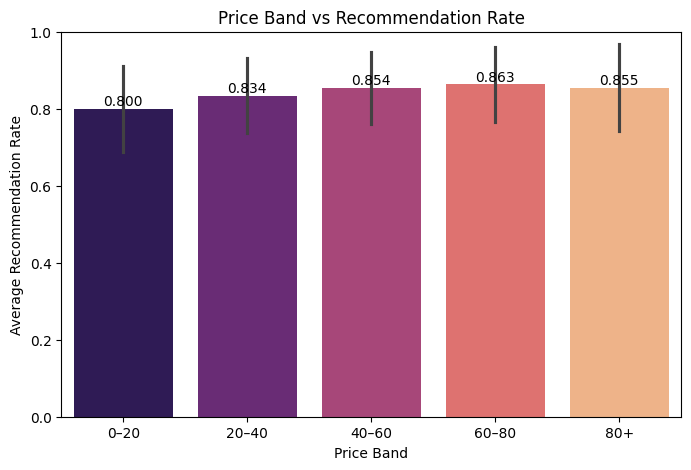

In [21]:
plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=price_bands_eda_df,
    x='price_band',
    y='recommendation_rate',
    errorbar='sd',           # show standard deviation as error bars
    palette='magma',
    hue='price_band',
    legend=False
)
plt.title('Price Band vs Recommendation Rate')
plt.xlabel('Price Band')
plt.ylabel('Average Recommendation Rate')
plt.ylim(0,1)         # since recommendation rate is 0-1

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f') # Use 3 decimal places for recommendation rate

plt.show()

In [22]:
# Analyze average rating by price band
rating_summary = price_bands_eda_df.groupby('price_band', observed=True)['rating'].agg(
    ['mean', 'std', 'count']
)

print("Average Rating by Price Band:")
print(rating_summary)

Average Rating by Price Band:
                mean       std  count
price_band                           
0–20        4.155057  0.402055    201
20–40       4.285557  0.328656    465
40–60       4.358885  0.302238    368
60–80       4.373017  0.314489    226
80+         4.357936  0.370277    173


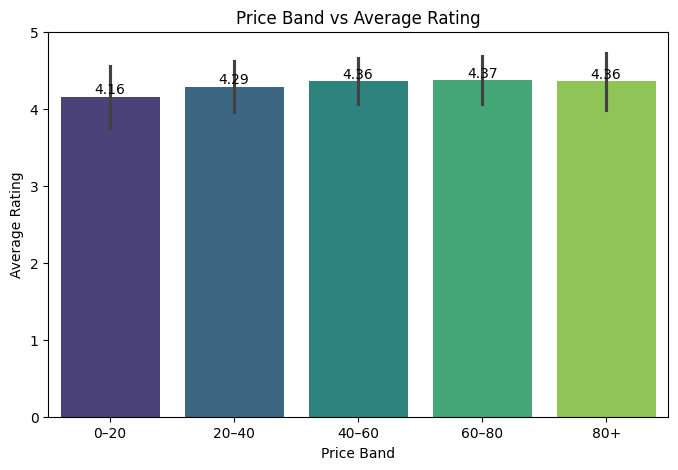

In [23]:
# Visualize average rating by price band
plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=price_bands_eda_df,
    x='price_band',
    y='rating',
    errorbar='sd',           # show standard deviation as error bars
    palette='viridis',
    hue='price_band',
    legend=False
)
plt.title('Price Band vs Average Rating')
plt.xlabel('Price Band')
plt.ylabel('Average Rating')
plt.ylim(0, 5)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.show()

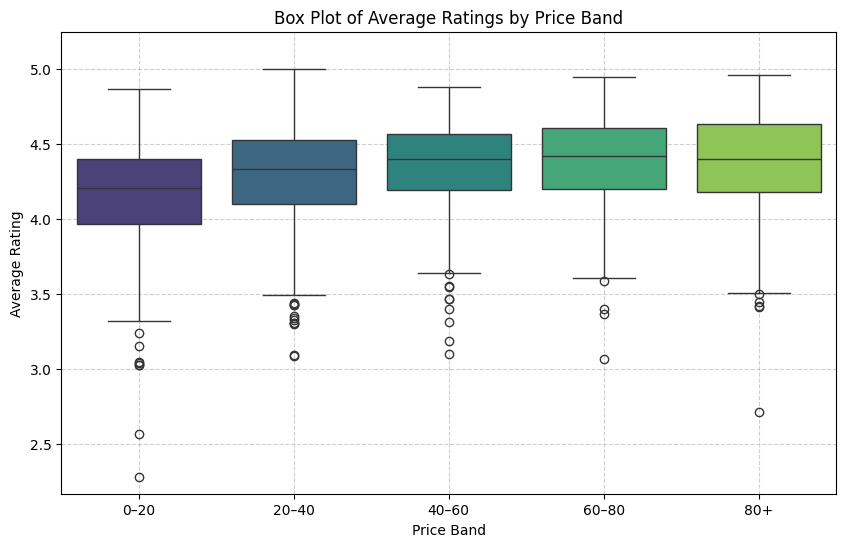

In [24]:
# Visualize the distribution of average ratings across price bands using a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=price_bands_eda_df,
    x='price_band',
    y='rating',
    palette='viridis',
    hue='price_band', # Assign x variable to hue for clarity
    legend=False      # Set legend to False
)
plt.title('Box Plot of Average Ratings by Price Band')
plt.xlabel('Price Band')
plt.ylabel('Average Rating')
plt.ylim(price_bands_eda_df['rating'].min() * 0.95, price_bands_eda_df['rating'].max() * 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [25]:
# Calculate the Pearson correlation coefficient
correlation = price_bands_eda_df['rating'].corr(price_bands_eda_df['recommendation_rate'])
print(f"Pearson Correlation between Average Rating and Recommendation Rate: {correlation:.4f}")

Pearson Correlation between Average Rating and Recommendation Rate: 0.9547


In [26]:
price_bands_eda_df['normalized_rating'] = price_bands_eda_df['rating'] / 5.0
price_bands_eda_df['combined_satisfaction'] = (price_bands_eda_df['normalized_rating'] + price_bands_eda_df['recommendation_rate']) / 2

print(price_bands_eda_df[['rating', 'normalized_rating', 'recommendation_rate', 'combined_satisfaction']].head())

   rating  normalized_rating  recommendation_rate  combined_satisfaction
0  4.0316            0.80632             0.708861               0.757590
1  4.4199            0.88398             0.871314               0.877647
2  4.4431            0.88862             0.871795               0.880207
4  4.5321            0.90642             0.797753               0.852086
5  4.6122            0.92244             0.821012               0.871726


In [27]:
combined_satisfaction_summary = price_bands_eda_df.groupby('price_band', observed=True)['combined_satisfaction'].agg(
    ['mean', 'std', 'count']
)

print("Combined Satisfaction Summary by Price Band:")
print(combined_satisfaction_summary)

Combined Satisfaction Summary by Price Band:
                mean       std  count
price_band                           
0–20        0.815313  0.095494    201
20–40       0.845706  0.080725    465
40–60       0.863005  0.076000    368
60–80       0.869006  0.079446    226
80+         0.863077  0.092080    173


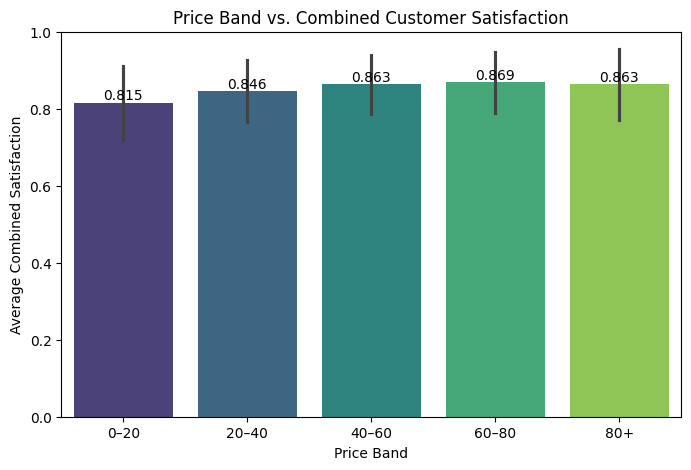

In [28]:
plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=price_bands_eda_df,
    x='price_band',
    y='combined_satisfaction',
    errorbar='sd',
    palette='viridis',
    hue='price_band',
    legend=False
)
plt.title('Price Band vs. Combined Customer Satisfaction')
plt.xlabel('Price Band')
plt.ylabel('Average Combined Satisfaction')
plt.ylim(0,1)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.show()

**Ingredients vs Customer Satisfaction Using Average Ratings**

In [29]:
product_df

,product_id,product_name,loves_count,rating,reviews,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category,price_band
89,P439055,GENIUS Sleeping Collagen Moisturizer,33910,4.5413,1321.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Ethylh...",98.0,"['Vegan', 'Good for: Loss of firmness', 'Colla...",Skincare,Moisturizers,Moisturizers,80+
90,P421277,GENIUS Liquid Collagen Serum,67870,4.0259,1159.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Propan...",115.0,"['Vegan', 'Good for: Loss of firmness', 'Colla...",Skincare,Treatments,Face Serums,80+
91,P467602,Triple Algae Eye Renewal Balm Eye Cream,17890,4.5306,1142.0,"['Aqua (Water/Eau), Stearic Acid, Isopropyl Is...",68.0,NaN,Skincare,Eye Care,Eye Creams & Treatments,60–80
92,P432045,GENIUS Liquid Collagen Lip Treatment,44448,3.8721,649.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Glycer...",29.0,"['Vegan', 'Good for: Loss of firmness', 'Plump...",Skincare,Lip Balms & Treatments,NaN,20–40
93,P311143,SUBLIME DEFENSE Ultra Lightweight UV Defense F...,27278,4.4134,508.0,"['Octinoxate 7.5%, Titanium Dioxide 2%, Zinc O...",28.0,"['Vegan', 'Hypoallergenic', 'UV Protection', '...",Skincare,Sunscreen,Face Sunscreen,20–40
...,...,...,...,...,...,...,...,...,...,...,...,...
8424,P501474,The Youth Vault: 13-Piece Vegan Skincare + App...,8989,4.8750,8.0,"['Superfood Antioxidant Cleanser:', 'Water/Aqu...",340.0,"['Clean at Sephora', 'Hydrating', 'Good for: A...",Skincare,Value & Gift Sets,NaN,NaN
8425,P502998,"Youth Stacks: Plump It Up for Dry, Dehydrated ...",10406,4.1667,6.0,"['Triple Peptide + Cactus Oasis Serum:', 'Wate...",28.0,"['Vegan', 'Hyaluronic Acid', 'Clean at Sephora...",Skincare,Value & Gift Sets,NaN,20–40
8426,P503872,Mini Mandelic Acid + Superfood Unity Exfoliant,6510,4.8000,5.0,"['Water/Aqua/Eau (Aqua), Helianthus Annuus (Su...",16.0,"['Clean + Planet Positive', 'Good for: Pores',...",Skincare,Cleansers,Toners,0–20
8427,P502977,Youth Stacks: Daily Skin Health Your Way for P...,13592,4.2500,4.0,"['Superfood Antioxidant Cleanser:', 'Water/Aqu...",20.0,"['Vegan', 'Good for: Pores', 'Clean + Planet P...",Skincare,Value & Gift Sets,NaN,0–20


In [30]:
import re

# Standardize ingredient text
product_df["ingredients_clean"] = (
    product_df["ingredients"]
    .str.lower()
    .str.replace(r"\([^)]*\)", "", regex=True)   # remove anything in parentheses
    .str.replace(r"[^a-z, ]", "", regex=True)    # remove special characters
)

# Split into list
product_df["ingredient_list"] = product_df["ingredients_clean"].str.split(",")

# Strip whitespace
product_df["ingredient_list"] = product_df["ingredient_list"].apply(
    lambda x: [i.strip() for i in x if i.strip() != ""]
)

In [31]:
product_df

,product_id,product_name,loves_count,rating,reviews,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category,price_band,ingredients_clean,ingredient_list
89,P439055,GENIUS Sleeping Collagen Moisturizer,33910,4.5413,1321.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Ethylh...",98.0,"['Vegan', 'Good for: Loss of firmness', 'Colla...",Skincare,Moisturizers,Moisturizers,80+,"collagen , water , ethylhexyl palmitate, oryza...","[collagen, water, ethylhexyl palmitate, oryza ..."
90,P421277,GENIUS Liquid Collagen Serum,67870,4.0259,1159.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Propan...",115.0,"['Vegan', 'Good for: Loss of firmness', 'Colla...",Skincare,Treatments,Face Serums,80+,"collagen , water , propanediol, isononyl isono...","[collagen, water, propanediol, isononyl isonon..."
91,P467602,Triple Algae Eye Renewal Balm Eye Cream,17890,4.5306,1142.0,"['Aqua (Water/Eau), Stearic Acid, Isopropyl Is...",68.0,NaN,Skincare,Eye Care,Eye Creams & Treatments,60–80,"aqua , stearic acid, isopropyl isostearate, di...","[aqua, stearic acid, isopropyl isostearate, di..."
92,P432045,GENIUS Liquid Collagen Lip Treatment,44448,3.8721,649.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Glycer...",29.0,"['Vegan', 'Good for: Loss of firmness', 'Plump...",Skincare,Lip Balms & Treatments,NaN,20–40,"collagen , water , glycerin, isononyl isononan...","[collagen, water, glycerin, isononyl isononano..."
93,P311143,SUBLIME DEFENSE Ultra Lightweight UV Defense F...,27278,4.4134,508.0,"['Octinoxate 7.5%, Titanium Dioxide 2%, Zinc O...",28.0,"['Vegan', 'Hypoallergenic', 'UV Protection', '...",Skincare,Sunscreen,Face Sunscreen,20–40,"octinoxate , titanium dioxide , zinc oxide , c...","[octinoxate, titanium dioxide, zinc oxide, cyc..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8424,P501474,The Youth Vault: 13-Piece Vegan Skincare + App...,8989,4.8750,8.0,"['Superfood Antioxidant Cleanser:', 'Water/Aqu...",340.0,"['Clean at Sephora', 'Hydrating', 'Good for: A...",Skincare,Value & Gift Sets,NaN,NaN,"superfood antioxidant cleanser, wateraquaeau, ...","[superfood antioxidant cleanser, wateraquaeau,..."
8425,P502998,"Youth Stacks: Plump It Up for Dry, Dehydrated ...",10406,4.1667,6.0,"['Triple Peptide + Cactus Oasis Serum:', 'Wate...",28.0,"['Vegan', 'Hyaluronic Acid', 'Clean at Sephora...",Skincare,Value & Gift Sets,NaN,20–40,"triple peptide cactus oasis serum, wateraquae...","[triple peptide cactus oasis serum, wateraqua..."
8426,P503872,Mini Mandelic Acid + Superfood Unity Exfoliant,6510,4.8000,5.0,"['Water/Aqua/Eau (Aqua), Helianthus Annuus (Su...",16.0,"['Clean + Planet Positive', 'Good for: Pores',...",Skincare,Cleansers,Toners,0–20,"wateraquaeau , helianthus annuus seed oil, st...","[wateraquaeau, helianthus annuus seed oil, st..."
8427,P502977,Youth Stacks: Daily Skin Health Your Way for P...,13592,4.2500,4.0,"['Superfood Antioxidant Cleanser:', 'Water/Aqu...",20.0,"['Vegan', 'Good for: Pores', 'Clean + Planet P...",Skincare,Value & Gift Sets,NaN,0–20,"superfood antioxidant cleanser, wateraquaeau, ...","[superfood antioxidant cleanser, wateraquaeau,..."


In [32]:
from collections import Counter

# Flatten ingredient lists
all_ingredients = [
    ingredient
    for sublist in product_df["ingredient_list"]
    for ingredient in sublist
]

ingredient_counts = Counter(all_ingredients)

ingredient_freq_df = pd.DataFrame(
    ingredient_counts.items(),
    columns=["ingredient", "count"]
).sort_values(by="count", ascending=False)

ingredient_freq_df.head(20)

,ingredient,count
5,glycerin,1935
33,phenoxyethanol,1356
44,butylene glycol,1129
20,tocopherol,1029
27,citric acid,981
25,ethylhexylglycerin,900
81,sodium hyaluronate,895
42,propanediol,888
186,xanthan gum,862
1,water,849


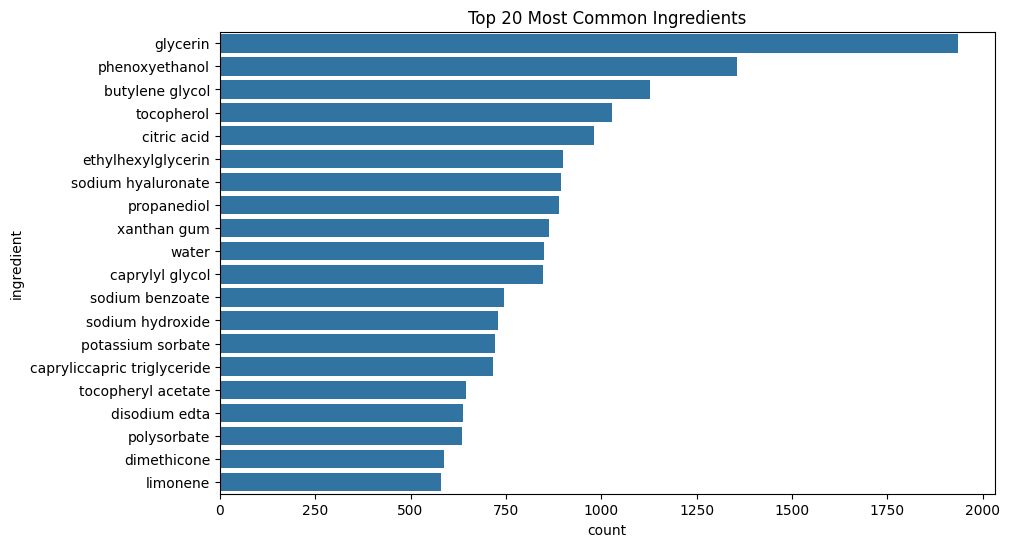

In [33]:
top20 = ingredient_freq_df.head(20)

plt.figure(figsize=(10,6))
sns.barplot(data=top20, x="count", y="ingredient")
plt.title("Top 20 Most Common Ingredients")
plt.show()

In [34]:
unique_product_counts = Counter(ing for sublist in product_df["ingredient_list"] for ing in set(sublist))

ingredient_product_unique_df = pd.DataFrame(unique_product_counts.items(), columns=["ingredient", "unique_product_count"]).sort_values("unique_product_count", ascending=False).reset_index(drop=True)

top_ingredients = ingredient_product_unique_df[ingredient_product_unique_df["unique_product_count"] >= 100]["ingredient"].tolist()

for ingredient in top_ingredients:
    product_df[ingredient] = product_df["ingredient_list"].apply(
        lambda x: 1 if ingredient in x else 0
    )
top_ingredients

C:\Users\charl\AppData\Local\Temp\ipykernel_21804\3054369847.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  product_df[ingredient] = product_df["ingredient_list"].apply(
C:\Users\charl\AppData\Local\Temp\ipykernel_21804\3054369847.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  product_df[ingredient] = product_df["ingredient_list"].apply(
C:\Users\charl\AppData\Local\Temp\ipykernel_21804\3054369847.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times,

['glycerin',
 'phenoxyethanol',
 'butylene glycol',
 'tocopherol',
 'citric acid',
 'sodium hyaluronate',
 'xanthan gum',
 'propanediol',
 'ethylhexylglycerin',
 'water',
 'caprylyl glycol',
 'capryliccapric triglyceride',
 'sodium benzoate',
 'sodium hydroxide',
 'potassium sorbate',
 'tocopheryl acetate',
 'disodium edta',
 'dimethicone',
 'squalane',
 'polysorbate',
 'limonene',
 'linalool',
 'pentylene glycol',
 'hexanediol',
 'wateraquaeau',
 'carbomer',
 'glyceryl stearate',
 'cetearyl alcohol',
 'helianthus annuus  seed oil',
 'lecithin',
 'silica',
 'sodium citrate',
 'niacinamide',
 'panthenol',
 'aquawatereau',
 'lactic acid',
 'fragrance',
 'camellia sinensis leaf extract',
 'sodium chloride',
 'caffeine',
 'cetyl alcohol',
 'acrylatesc alkyl acrylate crosspolymer',
 'geraniol',
 'citronellol',
 'chlorphenesin',
 'aqua',
 'butyrospermum parkii  butter',
 'stearic acid',
 'peg stearate',
 'aloe barbadensis leaf juice',
 'maltodextrin',
 'titanium dioxide',
 'sodium phytate',


In [35]:
ingredient_lift_results = []

for ingredient in top_ingredients:
    present = product_df[product_df[ingredient] == 1]["rating"]
    absent = product_df[product_df[ingredient] == 0]["rating"]

    lift = present.mean() - absent.mean()

    ingredient_lift_results.append({
        "ingredient": ingredient,
        "avg_rating_present": present.mean(),
        "avg_rating_absent": absent.mean(),
        "lift": lift,
        "count_present": present.count()
    })

ingredient_lift_df = pd.DataFrame(ingredient_lift_results)
ingredient_lift_df = ingredient_lift_df.sort_values(by="lift", ascending=False)

ingredient_lift_df.head(10)

,ingredient,avg_rating_present,avg_rating_absent,lift,count_present
79,bisabolol,4.363856,4.231322,0.132534,165
97,glycyrrhiza glabra root extract,4.338036,4.235121,0.102915,133
112,gluconolactone,4.331482,4.236166,0.095315,120
52,sodium phytate,4.324597,4.231295,0.093301,235
23,hexanediol,4.307248,4.223411,0.083838,464
96,potassium hydroxide,4.319943,4.236271,0.083671,134
115,saccharide isomerate,4.319015,4.237144,0.081871,114
120,phospholipids,4.314157,4.237528,0.076628,111
53,sodium pca,4.308785,4.233819,0.074966,220
75,glycolic acid,4.306898,4.235763,0.071135,173


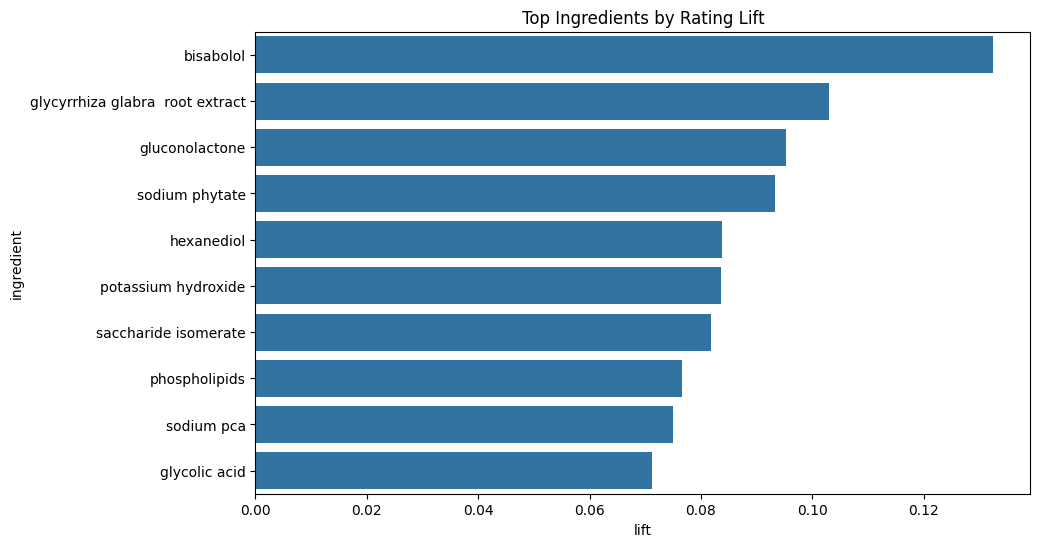

In [36]:
top_lift = ingredient_lift_df.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_lift, x="lift", y="ingredient")
plt.title("Top Ingredients by Rating Lift")
plt.show()

In [37]:
ingredient_lift_df = ingredient_lift_df[ingredient_lift_df["count_present"] > 20]

### Multivariate Linear Regression Model

**Feature Engineering**

In [38]:
def clean_highlights(val):
    if pd.isna(val) or str(val).strip() in ["", "[]"]:
        return []
    cleaned = re.sub(r"[\[\]'\"]", "", str(val))
    return [highlight.strip().lower() for highlight in cleaned.split(",") if highlight.strip()]

product_df["highlight_list"] = product_df["highlights"].apply(clean_highlights)

# Count number of products for each highlight
all_highlights = [h for sublist in product_df["highlight_list"] for h in sublist]
highlight_counts = Counter(all_highlights)

# Show all highlights and their frequency
highlight_freq_df = pd.DataFrame(highlight_counts.items(), columns=["highlight", "n_products"]).sort_values("n_products", ascending=False).reset_index(drop=True)
highlight_freq_df

C:\Users\charl\AppData\Local\Temp\ipykernel_21804\2967803855.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  product_df["highlight_list"] = product_df["highlights"].apply(clean_highlights)


,highlight,n_products
0,clean at sephora,658
1,good for: dullness/uneven texture,651
2,vegan,638
3,combo,575
4,normal skin,575
...,...,...
81,good for: damage,1
82,increases shine,1
83,warm &spicy scent,1
84,waterproof,1


In [39]:
selected_highlights = highlight_freq_df[highlight_freq_df["n_products"] >= 30]["highlight"].tolist()

highlights_cols = []
for highlight in selected_highlights:
    col = "highlight_" + re.sub(r"[^a-z0-9]", "_", highlight).strip("_")
    product_df[col] = product_df["highlight_list"].apply(lambda x: int(highlight in x))
    highlights_cols.append(col)

selected_highlights

C:\Users\charl\AppData\Local\Temp\ipykernel_21804\2891338838.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  product_df[col] = product_df["highlight_list"].apply(lambda x: int(highlight in x))
C:\Users\charl\AppData\Local\Temp\ipykernel_21804\2891338838.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  product_df[col] = product_df["highlight_list"].apply(lambda x: int(highlight in x))
C:\Users\charl\AppData\Local\Temp\ipykernel_21804\2891338838.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the 

['clean at sephora',
 'good for: dullness/uneven texture',
 'vegan',
 'combo',
 'normal skin',
 'cruelty-free',
 'good for: dryness',
 'good for: anti-aging',
 'hydrating',
 'without parabens',
 'hyaluronic acid',
 'good for: loss of firmness',
 'best for dry',
 'clean + planet positive',
 'good for: pores',
 'fragrance free',
 'best for oily',
 'vitamin c',
 'without sulfates sls & sles',
 'good for: dark circles',
 'good for: acne/blemishes',
 'good for: dark spots',
 'aha/glycolic acid',
 'niacinamide',
 'good for: redness',
 'salicylic acid',
 'gluten free',
 'without phthalates',
 'plumping',
 'spf',
 'best for dry skin',
 'oil free',
 'retinol',
 'alcohol free',
 'without silicones',
 'community favorite',
 'without mineral oil',
 'lactic acid',
 'hypoallergenic',
 'collagen',
 'refill available',
 'reef safe spf',
 'black owned at sephora',
 'radiant finish']

In [40]:
reliable_ingredients = ingredient_lift_df["ingredient"].tolist()
reliable_ingredients

['bisabolol',
 'glycyrrhiza glabra  root extract',
 'gluconolactone',
 'sodium phytate',
 'hexanediol',
 'potassium hydroxide',
 'saccharide isomerate',
 'phospholipids',
 'sodium pca',
 'glycolic acid',
 'ceramide np',
 'aquawatereau',
 'maltodextrin',
 'cetearyl glucoside',
 'kaolin',
 'salicylic acid',
 'sorbitan olivate',
 'helianthus annuus  seed oil',
 'wateraquaeau',
 'cococaprylatecaprate',
 'limonene',
 'chamomilla recutita  flower extract',
 'tocopherol',
 'curcuma longa  root extract',
 'lactic acid',
 'glucose',
 'niacinamide',
 'arginine',
 'cetearyl olivate',
 'rosmarinus officinalis  leaf extract',
 'leuconostocradish root ferment filtrate',
 'hydroxyacetophenone',
 'betaine',
 'parfumfragrance',
 'lavandula angustifolia  oil',
 'sodium stearoyl glutamate',
 'palmitoyl tripeptide',
 'stearyl alcohol',
 'hydrogenated lecithin',
 'behenyl alcohol',
 'citral',
 'simmondsia chinensis  seed oil',
 'sodium hydroxide',
 'geraniol',
 'squalane',
 'glyceryl caprylate',
 'sodium l

In [41]:
product_df

,product_id,product_name,loves_count,rating,reviews,ingredients,price_usd,highlights,primary_category,secondary_category,...,highlight_without_silicones,highlight_community_favorite,highlight_without_mineral_oil,highlight_lactic_acid,highlight_hypoallergenic,highlight_collagen,highlight_refill_available,highlight_reef_safe_spf,highlight_black_owned_at_sephora,highlight_radiant_finish
89,P439055,GENIUS Sleeping Collagen Moisturizer,33910,4.5413,1321.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Ethylh...",98.0,"['Vegan', 'Good for: Loss of firmness', 'Colla...",Skincare,Moisturizers,...,0,0,0,0,1,1,0,0,0,0
90,P421277,GENIUS Liquid Collagen Serum,67870,4.0259,1159.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Propan...",115.0,"['Vegan', 'Good for: Loss of firmness', 'Colla...",Skincare,Treatments,...,0,0,0,0,1,1,0,0,0,0
91,P467602,Triple Algae Eye Renewal Balm Eye Cream,17890,4.5306,1142.0,"['Aqua (Water/Eau), Stearic Acid, Isopropyl Is...",68.0,NaN,Skincare,Eye Care,...,0,0,0,0,0,0,0,0,0,0
92,P432045,GENIUS Liquid Collagen Lip Treatment,44448,3.8721,649.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Glycer...",29.0,"['Vegan', 'Good for: Loss of firmness', 'Plump...",Skincare,Lip Balms & Treatments,...,0,0,0,0,1,1,0,0,0,0
93,P311143,SUBLIME DEFENSE Ultra Lightweight UV Defense F...,27278,4.4134,508.0,"['Octinoxate 7.5%, Titanium Dioxide 2%, Zinc O...",28.0,"['Vegan', 'Hypoallergenic', 'UV Protection', '...",Skincare,Sunscreen,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8424,P501474,The Youth Vault: 13-Piece Vegan Skincare + App...,8989,4.8750,8.0,"['Superfood Antioxidant Cleanser:', 'Water/Aqu...",340.0,"['Clean at Sephora', 'Hydrating', 'Good for: A...",Skincare,Value & Gift Sets,...,0,0,0,0,0,0,0,0,0,0
8425,P502998,"Youth Stacks: Plump It Up for Dry, Dehydrated ...",10406,4.1667,6.0,"['Triple Peptide + Cactus Oasis Serum:', 'Wate...",28.0,"['Vegan', 'Hyaluronic Acid', 'Clean at Sephora...",Skincare,Value & Gift Sets,...,0,0,0,0,0,0,0,0,0,0
8426,P503872,Mini Mandelic Acid + Superfood Unity Exfoliant,6510,4.8000,5.0,"['Water/Aqua/Eau (Aqua), Helianthus Annuus (Su...",16.0,"['Clean + Planet Positive', 'Good for: Pores',...",Skincare,Cleansers,...,0,0,0,0,0,0,0,0,0,0
8427,P502977,Youth Stacks: Daily Skin Health Your Way for P...,13592,4.2500,4.0,"['Superfood Antioxidant Cleanser:', 'Water/Aqu...",20.0,"['Vegan', 'Good for: Pores', 'Clean + Planet P...",Skincare,Value & Gift Sets,...,0,0,0,0,0,0,0,0,0,0


In [42]:
product_df_model = final_df[final_df["total_reviews"] >= 50].reset_index(drop=True)
encoded_cols = reliable_ingredients + highlights_cols
product_df_model = product_df_model.merge(
    product_df[["product_id"] + encoded_cols],
    on="product_id",
    how="left"
)

In [43]:
# Features:
feature_cols = ["price_usd"] + reliable_ingredients + highlights_cols
model_df = product_df_model[["product_id", "product_name", "rating"] + feature_cols].dropna().reset_index(drop=True)

y = model_df["rating"]
X = model_df[feature_cols]

print(f"Target variable summary:")
print(y.describe().round(4))

Target variable summary:
count    1466.0000
mean        4.3092
std         0.3438
min         2.2820
25%         4.1310
50%         4.3608
75%         4.5515
max         5.0000
Name: rating, dtype: float64


**Multivariate Linear Regression Model Build**

In [44]:
import statsmodels.api as sm
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

In [45]:
# Fit OLS model:
X_const = sm.add_constant(X)
ols_model = sm.OLS(y, X_const).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.272
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     2.681
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           2.59e-23
Time:                        17:15:43   Log-Likelihood:                -281.90
No. Observations:                1466   AIC:                             923.8
Df Residuals:                    1286   BIC:                             1876.
Df Model:                         179                                         
Covariance Type:            nonrobust                                         
                                                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

In [46]:
# In-sample fit metrics
print(f"R squared: {ols_model.rsquared:.4f}")
print(f"Adj. R squared: {ols_model.rsquared_adj:.4f}")
print(f"p-value: {ols_model.f_pvalue:.4f}")
if ols_model.f_pvalue < 0.05:
    print("The overall model is statistically significant (p-value < 0.05)")
else:
    print("The overall model is NOT statistically significant (p-value >= 0.05)")

R squared: 0.2717
Adj. R squared: 0.1704
p-value: 0.0000
The overall model is statistically significant (p-value < 0.05)


In [47]:
# 5-fold cross-validated RMSE
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr = LinearRegression()

cv_r2   = cross_val_score(lr, X, y, cv=kf, scoring="r2")
cv_rmse = np.sqrt(-cross_val_score(lr, X, y, cv=kf, scoring="neg_mean_squared_error"))

print(f"Cross-Validated R²: {cv_r2.mean():.4f}  (std: {cv_r2.std():.4f})")
print(f"Cross-Validated RMSE: {cv_rmse.mean():.4f}  (std: {cv_rmse.std():.4f}) rating points")
print(f"On unseen products, the model's predictions are off by ~{cv_rmse.mean():.2f} rating points")

Cross-Validated R²: 0.0290  (std: 0.0632)
Cross-Validated RMSE: 0.3380  (std: 0.0260) rating points
On unseen products, the model's predictions are off by ~0.34 rating points


### Predict Using Model

In [48]:
# Predict using new product features:
# Product: EADEM Le Chouchou Exfoliating + Softening Peptide Lip Balm
new_price = 24.00
new_ingredients = ["Collagen-Boosting Peptide", "Hydrogenated Polyisobutene", "Diisostearyl Malate", "Tridecyl Trimellitate", "Phytosteryl/Isostearyl/Cetyl/Stearyl/Behenyl Dimer Dilinoleate", "Bis-Diglyceryl Polyacyladipate-2", "Methyl Hydrogenated Rosinate", "Polyphenylsilsesquioxane", "Pentaerythrityl Tetraisostearate", "Ethylene/Propylene/Styrene Copolymer", "Synthetic Wax", "Silica Silylate", "VP/Hexadecene Copolymer", "Hibiscus Sabdariffa Flower Extract", "Butyrospermum Parkii (Shea) Butter", "Euterpe Oleracea Fruit Oil", "Schinziophyton Rautanenii Kernel Oil", "Tocopherol", "Microcrystalline Wax", "Moringa Oil/Hydrogenated Moringa Oil Esters", "Isostearyl Alcohol", "Water", "Ethylhexyl Palmitate", "Octyldodecanol", "Caprylic", "Tribehenin", "Sorbitan Isostearate", "Propylene Carbonate", "Stearalkonium Hectorite", "Lactic Acid", "Palmitoyl Hexapeptide-12", "Palmitoyl Tripeptide-1", "Butylene/Ethylene/Styrene Copolymer", "Pentaerythrityl Tetra-di-t-butyl Hydroxyhydrocinnamate"]
new_highlights = ["cruelty-free", "peptide", "clean at sephora", "best for dry, combo, normal skin", "good for: dryness", "aha/glycolic acid"]

# Build the feature vector for this product
new_row = {"price_usd": new_price}
for ingredient in reliable_ingredients:
    new_row[ingredient] = int(ingredient in [i.lower().strip() for i in new_ingredients])

for highlight, col in zip(selected_highlights, highlights_cols):
    new_row[col] = int(highlight in [h.lower().strip() for h in new_highlights])

new_X = pd.DataFrame([new_row])[feature_cols]
new_X_const = sm.add_constant(new_X, has_constant='add')
prediction = ols_model.predict(new_X_const)[0]
pred_ci = ols_model.get_prediction(new_X_const).conf_int(alpha=0.05)[0]
matched_ingredients = [i for i in reliable_ingredients if new_row[i] == 1]
matched_highlights  = [h for h, col in zip(selected_highlights, highlights_cols) if new_row[col] == 1]

print("PREDICTED PRODUCT RATING")
print(f"Price: ${new_price:.2f}")
print(f"Matched Ingredients: {', '.join(matched_ingredients) if matched_ingredients else 'None'}")
print(f"Matched Highlights: {', '.join(matched_highlights) if matched_highlights else 'None'}")
print(f"Predicted Rating: {prediction:.3f} / 5.0")
print(f"95% Prediction Interval: [{pred_ci[0]:.3f}, {pred_ci[1]:.3f}]")

PREDICTED PRODUCT RATING
Price: $24.00
Matched Ingredients: tocopherol, lactic acid, sorbitan isostearate, water
Matched Highlights: clean at sephora, cruelty-free, good for: dryness, aha/glycolic acid
Predicted Rating: 4.179 / 5.0
95% Prediction Interval: [4.008, 4.349]
